In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Setting floating point to 2 decimal places
pd.options.display.float_format = '{:.2f}'.format

In [3]:
# Getting into file directory.
project_path = os.environ.get('PROJECT_PATH')
data_file = r'EDA\Diwali sales\data\Diwali Sales Data.csv'
file_path = os.path.join(project_path, data_file)

# Reading data file
df = pd.read_csv(file_path)

### --> Overview of Dataset

In [4]:
# What dataset looks like
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN


In [5]:
# Shape of dataset
shape= df.shape
print(f"There are {shape[0]} rows and {shape[1]} columns in the given dataset!")

There are 11251 rows and 15 columns in the given dataset!


In [6]:
# Checking data types of all the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
# Checking for Null values and counts
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [8]:
# Statistical Model of the dataset for a quick overview
df.describe(include='all')

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
count,11251.00,11251,11251,11251,11251,11251.00,11251.00,11251,11251,11251,11251,11251.00,11239.00,0.00,0.00
unique,NaN,1250,2351,2,7,NaN,NaN,16,5,15,18,NaN,NaN,NaN,NaN
top,NaN,Vishakha,P00265242,F,26-35,NaN,NaN,Uttar Pradesh,Central,IT Sector,Clothing & Apparel,NaN,NaN,NaN,NaN
freq,NaN,42,53,7842,4543,NaN,NaN,1946,4296,1588,2655,NaN,NaN,NaN,NaN
mean,1003004.49,NaN,NaN,NaN,NaN,35.42,0.42,NaN,NaN,NaN,NaN,2.49,9453.61,NaN,NaN
std,1716.13,NaN,NaN,NaN,NaN,12.75,0.49,NaN,NaN,NaN,NaN,1.12,5222.36,NaN,NaN
min,1000001.00,NaN,NaN,NaN,NaN,12.00,0.00,NaN,NaN,NaN,NaN,1.00,188.00,NaN,NaN
25%,1001492.00,NaN,NaN,NaN,NaN,27.00,0.00,NaN,NaN,NaN,NaN,1.50,5443.00,NaN,NaN
50%,1003065.00,NaN,NaN,NaN,NaN,33.00,0.00,NaN,NaN,NaN,NaN,2.00,8109.00,NaN,NaN
75%,1004430.00,NaN,NaN,NaN,NaN,43.00,1.00,NaN,NaN,NaN,NaN,3.00,12675.00,NaN,NaN


### --> Some Data Cleaning and Standardization

In [9]:
# Standardizing all column names to lowercase with underscores in between
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN


In [10]:
# Removing Null columns
df = df.drop(columns=['status', 'unnamed1'])

In [11]:
# Data with null amount values
missing_amount = df[df['amount'].isnull()]
df = df.drop(missing_amount.index, axis=0)

In [12]:
# Adding Column for marital status 0 for unmarried and 1 for married
df['married_or_not'] = df['marital_status'].map({0:'Un-married', 1: 'Married'})
df.head()

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,married_or_not
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,Un-married
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,Married
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,Married
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,Un-married
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,Married


### --> Sales Distribution by Age Group and Orders

In [13]:
# Average purchase of each age group
age_group = df.groupby('age_group').agg(total_sales=('amount', 'sum'), mean_amount=('amount', 'mean'),
                                        median_amount=('amount', 'median'), count_orders=('orders', 'count'))
age_group['mean-median_deviation'] = age_group['mean_amount'] - age_group['median_amount']
age_group.sort_values(by=['total_sales', 'count_orders'], ascending=False)

,total_sales,mean_amount,median_amount,count_orders,mean-median_deviation
age_group,,,,,
26-35,42613443.94,9384.15,8100.00,4541,1284.15
36-45,22144995.49,9699.95,8225.00,2283,1474.95
18-25,17240732.00,9175.48,8015.00,1879,1160.48
46-50,9207844.00,9367.08,8088.00,983,1279.08
51-55,8261477.00,9953.59,8575.50,830,1378.09
55+,4080987.00,9557.35,8187.00,427,1370.35
0-17,2699653.00,9120.45,7975.00,296,1145.45


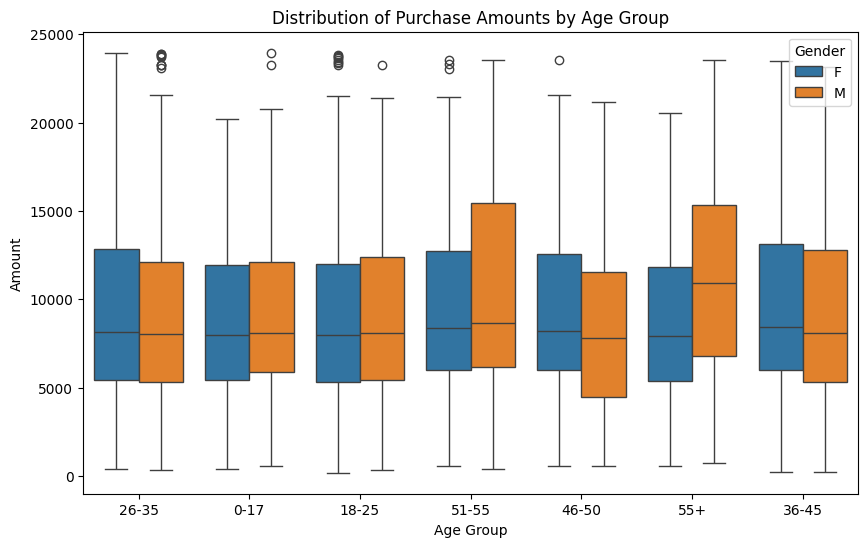

In [14]:
# Make the figure a bit wider
plt.figure(figsize=(10, 6)) 

# Plot using age_group instead of age
ax = sns.boxplot(data=df, x='age_group', y='amount', hue='gender')

plt.title('Distribution of Purchase Amounts by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Amount')
ax.legend(title='Gender', loc='upper right')
plt.show()

### --> Which gender made the most revenue

In [15]:
revenue_by_gender = df.groupby(['gender', 'married_or_not']).agg(TotalSales=('amount', 'sum'),
                                                       Count=('amount', 'count'),
                                                     MedianSales=('amount', 'median'),
                                                    MaritalStatus=('married_or_not', 'count')
                                            )
revenue_by_gender.sort_values(by=['TotalSales', 'Count'], ascending=False)

TotalSales  Count  MedianSales  MaritalStatus
gender married_or_not                                               
F      Un-married     43786648.44   4573      8141.00           4573
       Married        30549207.99   3259      8083.00           3259
M      Un-married     18338738.00   1945      8119.00           1945
       Married        13574538.00   1462      8051.50           1462

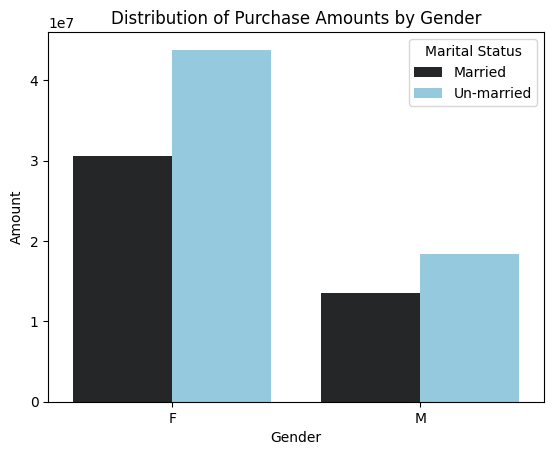

In [16]:
# Creating Title and labels
plt.title('Distribution of Purchase Amounts by Gender')
plt.xlabel('Gender')
plt.ylabel('Amount')

# Box plot for distribution of amount spent across different gender and marital status
ax = sns.barplot(
    data=revenue_by_gender,
    x='gender',
    y='TotalSales',
    palette='dark:skyblue',
    hue='married_or_not'
)

# Changing legend axis title
ax.legend(title='Marital Status')

plt.show()

### --> Distribution of Sales by Occupation

In [17]:
# Purchases count and sales as per occupation 
# To see which sector generating more revenue 
occupation_revenue = df.groupby('occupation').agg(total_sales=('amount', 'sum'),
                                                 total_count=('amount', 'count'),
                                                 total_orders=('orders', 'sum'))
occupation_revenue['amount_per_order'] = occupation_revenue['total_sales'] / occupation_revenue['total_orders']
occupation_revenue.sort_values(by=['total_sales', 'total_count', 'total_orders'], ascending=False, inplace=True)
occupation_revenue

,total_sales,total_count,total_orders,amount_per_order
occupation,,,,
IT Sector,14755079.00,1583,3997,3691.54
Healthcare,13034587.49,1408,3455,3772.67
Aviation,12602298.00,1310,3215,3919.84
Banking,10770610.95,1137,2817,3823.43
Govt,8517212.00,854,2155,3952.30
Hospitality,6376405.00,703,1739,3666.71
Media,6295832.99,637,1596,3944.76
Automobile,5368596.00,565,1371,3915.82
Chemical,5297436.00,541,1309,4046.93


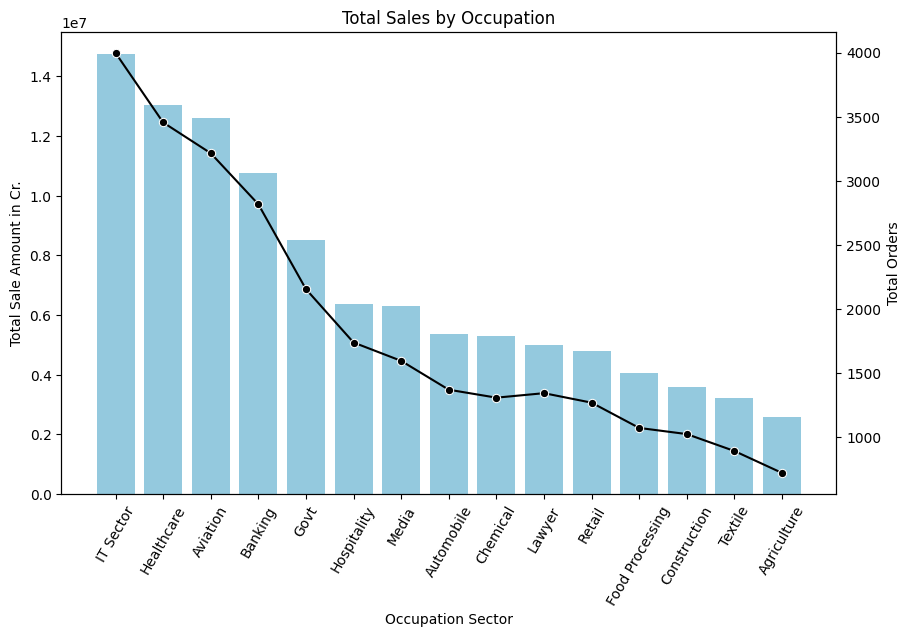

In [18]:
# Creating figure and primary axis (ax1)
fig, ax1 = plt.subplots(figsize=(10, 6))

plt.title('Total Sales by Occupation')
plt.xlabel('Occupation Sector')
plt.ylabel('Total Sale Amount in Cr.')
plt.xticks(rotation=60)

# Plotting Total sales by occupation
sns.barplot(
    data=occupation_revenue, 
    x='occupation', 
    y='total_sales',
    color='skyblue', 
    ax=ax1
)

# Create a secondary axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# Plot the lineplot on the secondary axis (ax2)
sns.lineplot(
    data=occupation_revenue, 
    x='occupation', 
    y='total_orders',
    color='black',
    marker='o',
    ax=ax2,
)
ax2.set_ylabel('Total Orders')

plt.show()

### --> Correlation Analysis

In [19]:
# Correlation of Numerical columns
corr_matrix = df.corr(numeric_only=True)

<Axes: >

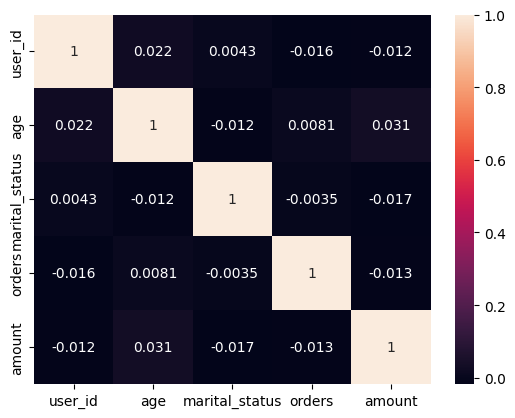

In [20]:
# Plotting heatmap
sns.heatmap(data=corr_matrix, annot=True)

### --> Encoding Text columns based on median values
Standard correlation heatmaps only understand numbers, so they ignore text categories like 'Product Category' or 'State'. 
To measure how strongly these categories affect sales, I applied Median Encoding. This process replaces the text label 
(e.g., 'Food') with the median sales amount for that specific category. By translating categories into their 'financial weight',
the heatmap can mathematically calculate if a specific category is a strong predictor of the final sales amount."

In [21]:
"""
# The above heatmap has no correlation whatsoever
# Will change the methodology to include text columns such as:
    - age_group, gender, occupation, product_category
# We will encode these columns based on median total_sales
"""
# Creating copy of dataframe
df2 = df.copy()

# Encoding gender into numerical
gender_median = df2.groupby('gender')['amount'].median()
df2['gender_encoded'] = df2['gender'].map(gender_median)

# Encoding product category
prod_cat_median = df2.groupby('product_category')['amount'].median()
df2['prod_cat_encoded'] = df2['product_category'].map(prod_cat_median)

# Encoding occupation
occu_median = df2.groupby('occupation')['amount'].median()
df2['occu_encoded'] = df2['occupation'].map(occu_median)

# Encoding state
state_median = df2.groupby('state')['amount'].median()
df2['state_encoded'] = df2['state'].map(state_median)

# Encoding zone
zone_median = df2.groupby('zone')['amount'].median()
df2['zone_encoded'] = df2['zone'].map(zone_median)

# Checking the new dataframe
df2.head()

,user_id,cust_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,married_or_not,gender_encoded,prod_cat_encoded,occu_encoded,state_encoded,zone_encoded
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,Un-married,8114.00,19295.00,8085.50,8299.00,8251.00
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,Married,8114.00,19295.00,8638.00,8103.00,8363.00
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,Married,8114.00,19295.00,8281.00,8648.50,8416.00
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,Un-married,8094.00,19295.00,7772.50,9824.50,8363.00
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,Married,8094.00,19295.00,8096.00,8110.00,8251.00


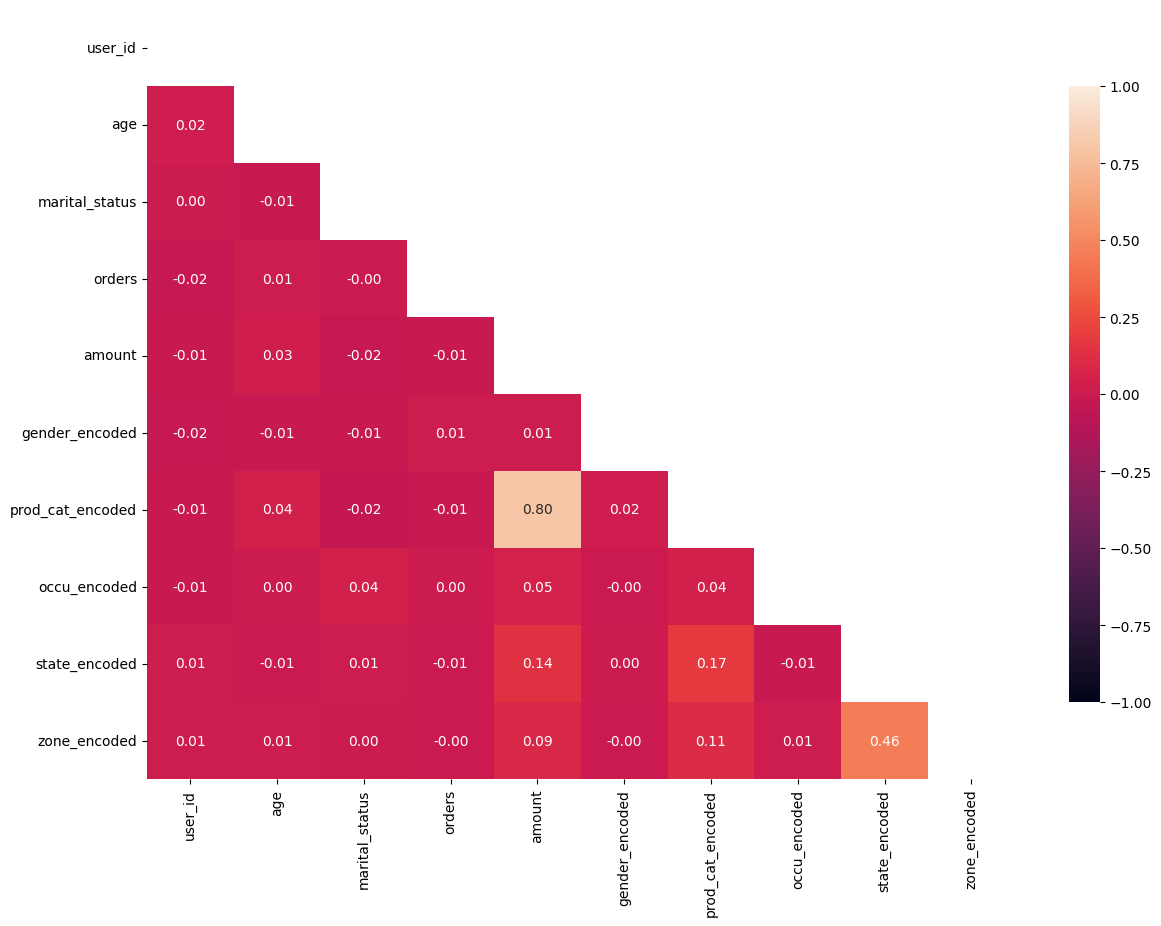

In [22]:
# Creating heatmap again Using Encoded text columns
corr_matrix_all = df2.corr(numeric_only=True)

# Creating mask to hide upper triangle (removes duplicate visual clutter)
mask = np.triu(np.ones_like(corr_matrix_all, dtype=bool))

# Setting up matplotlib figsize
plt.figure(figsize=(14, 10))
sns.heatmap(
    data=corr_matrix_all, 
    cbar_kws={"shrink": .8}, 
    vmin=-1, 
    vmax=1, 
    annot=True,
    mask=mask,
    fmt='.2f')
plt.show()

<i>The encoded heatmap shows a massive 0.80 correlation between prod_cat_encoded and amount . Add a short text note acknowledging that while encoding artificially inflates this number, it definitively proves that Product Category is the primary driver of purchase price.

### --> Revenue by Product Category

In [23]:
# Distribution of sales as per Category and total orders
rev_by_product_cat = df.groupby('product_category').agg(total_sales=('amount', 'sum'),
                                                       total_orders=('orders', 'count'),
                                                       avg_amount_per_order=('amount', 'median'))
rev_by_product_cat = rev_by_product_cat.sort_values(by=['total_sales', 'avg_amount_per_order'], ascending=False)
rev_by_product_cat.head()

,total_sales,total_orders,avg_amount_per_order
product_category,,,
Food,33933883.50,2490,15232.00
Clothing & Apparel,16495019.00,2655,6919.00
Electronics & Gadgets,15643846.00,2087,7903.00
Footwear & Shoes,15575209.45,1059,16289.00
Furniture,5440051.99,352,16277.50


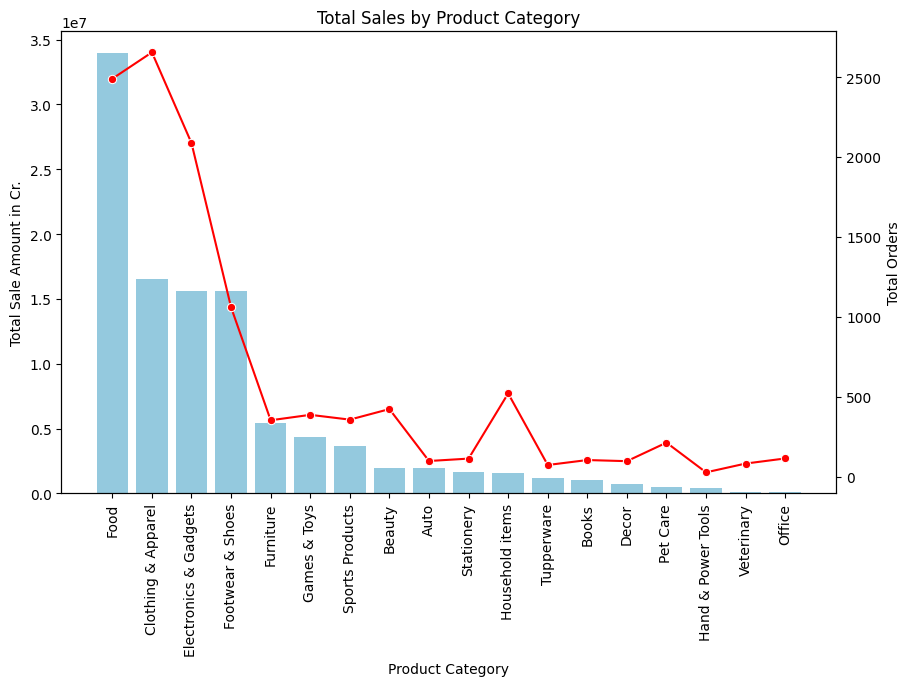

In [24]:
# Plotting chart for revenue by category

# Creating figure and primary axis (ax1)
fig, ax1 = plt.subplots(figsize=(10, 6))

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sale Amount in Cr.')
plt.xticks(rotation=90)

# Plotting Total sales by occupation
sns.barplot(
    data=rev_by_product_cat, 
    x='product_category', 
    y='total_sales',
    color='skyblue', 
    ax=ax1
)

# Create a secondary axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# Plot the lineplot on the secondary axis (ax2)
sns.lineplot(
    data=rev_by_product_cat, 
    x='product_category', 
    y='total_orders',
    color='red',
    marker='o',
    ax=ax2,
)
ax2.set_ylabel('Total Orders')

plt.show()

#### Average Sales for each product category with total orders

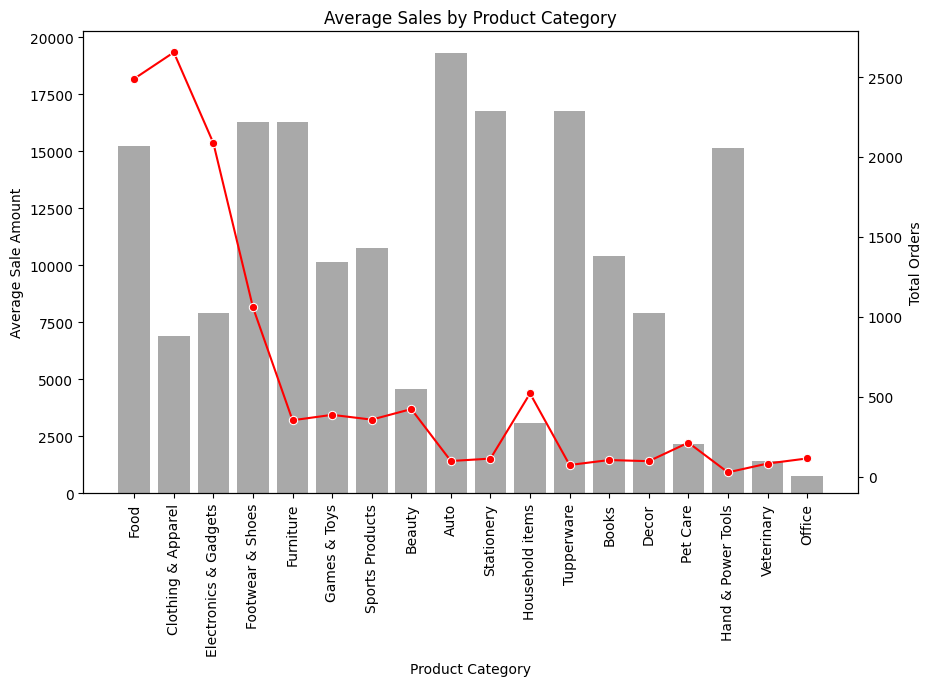

In [25]:
# Plotting chart for average revenue by category

# Creating figure and primary axis (ax1)
fig, ax1 = plt.subplots(figsize=(10, 6))

plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Sale Amount')
plt.xticks(rotation=90)

# Plotting Total sales by occupation
sns.barplot(
    data=rev_by_product_cat, 
    x='product_category', 
    y='avg_amount_per_order',
    color='darkgrey', 
    ax=ax1
)

# Create a secondary axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# Plot the lineplot on the secondary axis (ax2)
sns.lineplot(
    data=rev_by_product_cat, 
    x='product_category', 
    y='total_orders',
    color='red',
    marker='o',
    ax=ax2,
)
ax2.set_ylabel('Total Orders')

plt.show()

### --> Revenue by State

In [26]:
revenue_by_state = df.groupby('state').agg(total_sales=('amount', 'sum'),
                                                       total_orders=('orders', 'count'),
                                                       avg_amount_per_order=('amount', 'median'))
revenue_by_state = revenue_by_state.sort_values(by=['total_sales', 'avg_amount_per_order'], ascending=False)
revenue_by_state.head()

,total_sales,total_orders,avg_amount_per_order
state,,,
Uttar Pradesh,19374968.00,1944,8648.50
Maharashtra,14427543.00,1525,8299.00
Karnataka,13523540.00,1304,9824.50
Delhi,11603819.45,1104,9950.50
Madhya Pradesh,8101142.00,921,7799.00


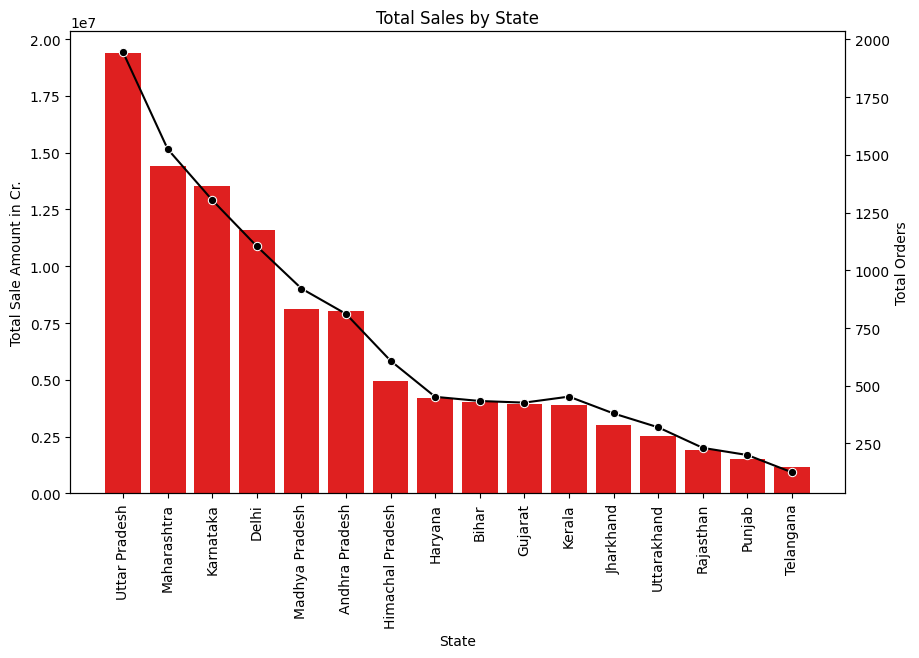

In [27]:
# Plotting chart for revenue by state

# Creating figure and primary axis (ax1)
fig, ax1 = plt.subplots(figsize=(10, 6))

plt.title('Total Sales by State')
plt.xlabel('State')
plt.ylabel('Total Sale Amount in Cr.')
plt.xticks(rotation=90)

# Plotting Total sales by occupation
sns.barplot(
    data=revenue_by_state, 
    x='state', 
    y='total_sales',
    color='red', 
    ax=ax1
)

# Create a secondary axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

# Plot the lineplot on the secondary axis (ax2)
sns.lineplot(
    data=revenue_by_state, 
    x='state', 
    y='total_orders',
    color='black',
    marker='o',
    ax=ax2,
)
ax2.set_ylabel('Total Orders')

plt.show()